<a href="https://colab.research.google.com/github/faizaan0619/MachineLearning/blob/main/Supervised/KNN_iris_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
iris = load_iris()

In [34]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [36]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=6)

In [37]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(iris['data'], iris['target'], random_state=0)

In [38]:
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

In [39]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_pred))

0.9736842105263158


In [40]:
from sklearn.model_selection import cross_val_score

k_range = range(1, 21)
cv_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, iris.data, iris.target, cv=5)
    cv_scores.append(scores.mean())

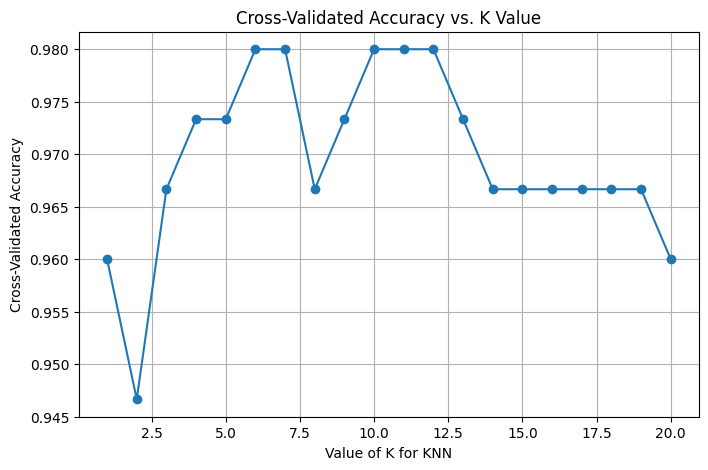

In [41]:
plt.figure(figsize=(8,5))
plt.plot(k_range, cv_scores, marker='o')
plt.title('Cross-Validated Accuracy vs. K Value')
plt.xlabel('Value of K for KNN')
plt.ylabel('Cross-Validated Accuracy')
plt.grid()
plt.show()

In [42]:
import numpy as np
best_k = k_range[np.argmax(cv_scores)]
print(best_k)

6


In [43]:
X = iris.data
y = iris.target

In [44]:
# Taking only Petal Length and Petal Width
X = X[:, [2, 3]]

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [46]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [47]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

KNeighborsClassifier()

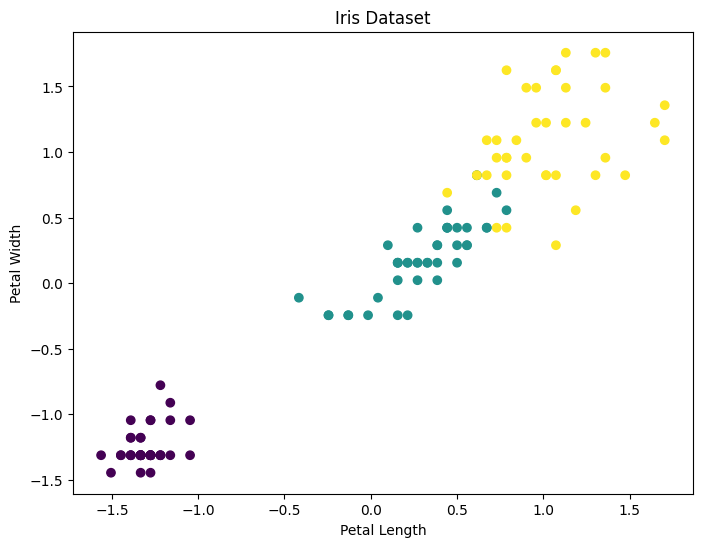

In [48]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=y_train
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Iris Dataset")

plt.show()

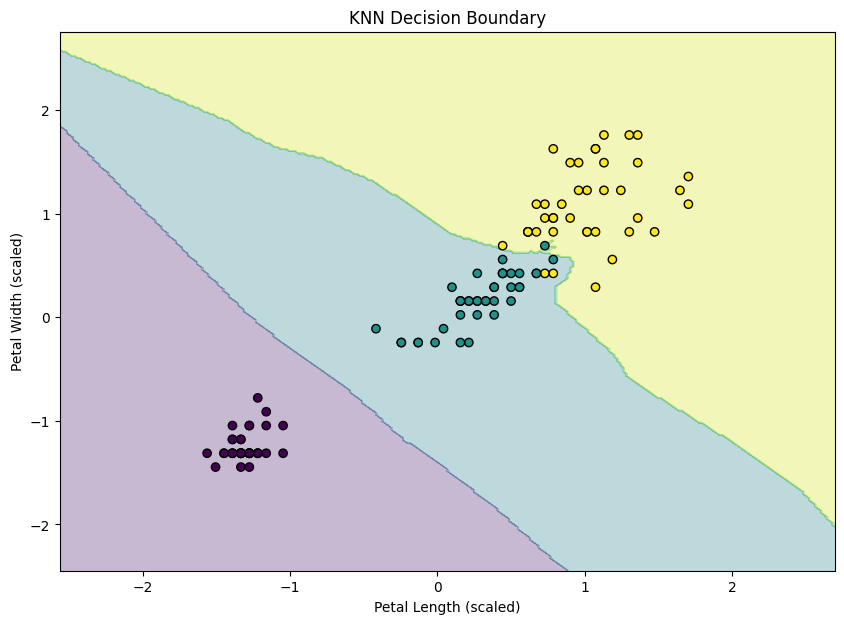

In [49]:
# Create a grid covering the entire feature space
x_min = X_train[:, 0].min() - 1
x_max = X_train[:, 0].max() + 1

y_min = X_train[:, 1].min() - 1
y_max = X_train[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

# Predict every point in the grid
grid_points = np.c_[xx.ravel(), yy.ravel()]

Z = knn.predict(grid_points)

Z = Z.reshape(xx.shape)

# Plot decision regions
plt.figure(figsize=(10, 7))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.3
)

# Plot training points
plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=y_train,
    edgecolor="black"
)

plt.xlabel("Petal Length (scaled)")
plt.ylabel("Petal Width (scaled)")
plt.title("KNN Decision Boundary")

plt.show()